In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
from qutip.qip.operations import rz, cz_gate
from tqdm import tqdm
from matplotlib.colors import LogNorm
import pytz, cmath, itertools
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from joblib import Parallel, delayed
import scipy.sparse as ssp
from sympy import symbols
import utils_2Q_gate_zp as ut
import pandas as pd
import scipy as sp
from multiprocessing import Pool
import qutip as qt
import multiprocessing as mp
import scqubits as scq
from sympy import symbols
import scipy.sparse as ssp
from datetime import datetime
import ham_data as hd
import os
import tempfile
import shutil

# calc decay / dephasing rate for Coupled zero pi

In [2]:
t1_other = 1 # μs
gamma_decay_other =  1 / 1e3 / t1_other # 1e-3 GHz
gamma_dephase_other = 1 / 1e3 / t1_other
state_mid = 8

folder_2q = '../data/Two_qubit_data_Sorted_Untruc'
[hspace_full, _, _, _, _, hspace_0, hspace_1, hspace_n_theta1, hspace_n_theta2, _
] = hd.load_two_qubit_data(folder_2q)

eval0,eval1,n_theta0,n_theta1 = hd.load_1q_data_for_2q(folder_2q)
eval0 = eval0 - eval0[0]
eval1 = eval1 - eval1[0]

qubit_map = {
    "q0": {
        "n_theta": n_theta0,
        "hspace": hspace_0,
        "flux_deriv_path": "../data/data_flux_derivative_q0_eval_300_cpu_100.npz",
    },
    "q1": {
        "n_theta": n_theta1,
        "hspace": hspace_1,
        "flux_deriv_path": "../data/data_flux_derivative_q1_eval_300_cpu_100.npz",
    },
}

### $T_\phi$

In [ ]:
d2w_dphi2 = {}  # Store raw second derivatives indexed by qubit label.
d2w_dphi2_by_label = {}  # Store reordered second derivatives in each label's target subspace order.
idx_mid = {}  # Store the index of `state_mid` inside each label's Hilbert-space ordering.
A_02 = {}  # Store per-label scaling factor A fixed by the |0>-|2> dephasing target.
gamma_tphi_1us_02 = {}  # Store computed dephasing rates corresponding to tphi = 1 us.

for label, cfg in qubit_map.items():  # Loop over each qubit configuration (for example q0 and q1).
    q = np.load(cfg["flux_deriv_path"])  # Load precomputed flux-derivative data from .npz.
    x = np.asarray(q["param_vals"])      # Read flux sweep points as a 1D array with shape (N,).
    y = np.asarray(q["energy_table"])    # Read energy table as a 2D array with shape (N, M).

    dx = np.diff(x)                       # Compute neighboring flux spacing with shape (N-1,).
    dy = np.diff(y, axis=0)               # Compute neighboring energy differences along flux axis, shape (N-1, M).

    # Compute first derivative dE/dphi on the midpoint grid between original flux points.
    dydx = dy / dx[:, None]               # Divide element-wise to get first derivative, shape (N-1, M).
    x_mid = 0.5 * (x[1:] + x[:-1])        # Build midpoint coordinates corresponding to `dydx`, shape (N-1,).

    # Compute second derivative d2E/dphi2 on the midpoint-of-midpoint grid.
    d2ydx2 = np.diff(dydx, axis=0) / np.diff(x_mid)[:, None]  # Second derivative array with shape (N-2, M).

    # Keep only the first flux-index slice to stay consistent with previous workflow.
    d2w_dphi2[label] = d2ydx2[0, :]  # Save per-state second derivative at the first available index.

    # Reorder values to align with the target subspace ordering required downstream.
    # hspace = cfg["hspace"]  # Target Hilbert-space index ordering for this label.
    # idx_mid[label] = hspace.index(state_mid)  # Record where the selected middle state appears in `hspace`.
    d2w_dphi2_by_label[label] = [d2w_dphi2[label][i] for i in cfg["hspace"]]  # Reindex derivative values by `hspace`.

    #################
    # Calibrate scaling A by forcing the |0>-|2> channel to match `gamma_dephase_other` at tphi = 1 us.
    d2w_dphi2_target = d2w_dphi2 # without charge trunction
    # d2w_dphi2_target = d2w_dphi2_by_label # with charge trunction
    
    A_02[label] = gamma_dephase_other / d2w_dphi2_target[label][2]  # Use index 2 corresponding to |0>-|2>.

    gamma_tphi_1us_02[label] = A_02[label] * np.array(d2w_dphi2_target[label])  # Apply scaling to all reordered states.

for i in range(10):  # Print the first 10 mapped states for q0 and q1 for quick inspection.
    print( f"d2w_dphi2_target[{i}]={d2w_dphi2_target['q0'][i]:.2e},    "  # Format q0 dephasing at index i.
        + f" d2w_dphi2_target[{i}]={d2w_dphi2_target['q1'][i]:.2e}" )  # Append q1 dephasing at index i.   
for i in range(10):  # Print the first 10 mapped states for q0 and q1 for quick inspection.
    print( f"gamma_phi_q0[{i}]={gamma_tphi_1us_02['q0'][i]:.2e},    "  # Format q0 dephasing at index i.
        + f" gamma_phi_q1[{i}]={gamma_tphi_1us_02['q1'][i]:.2e}" )  # Append q1 dephasing at index i.     

# for i in range(10):  # Print the first 10 mapped states for q0 and q1 for quick inspection.
#     print( f"gamma_phi_q0[{hspace_0[i]}]={gamma_tphi_1us_02['q0'][i]:.2e},    "  # Format q0 dephasing at index i.
#         + f" gamma_phi_q1[{hspace_1[i]}]={gamma_tphi_1us_02['q1'][i]:.2e}" )  # Append q1 dephasing at index i.           

d2w_dphi2_target[0]=0.00e+00,     d2w_dphi2_target[0]=0.00e+00
d2w_dphi2_target[1]=-6.96e-01,     d2w_dphi2_target[1]=6.03e-01
d2w_dphi2_target[2]=-3.91e+03,     d2w_dphi2_target[2]=-2.41e+03
d2w_dphi2_target[3]=3.91e+03,     d2w_dphi2_target[3]=2.41e+03
d2w_dphi2_target[4]=4.43e-01,     d2w_dphi2_target[4]=1.89e-01
d2w_dphi2_target[5]=-1.14e+03,     d2w_dphi2_target[5]=-6.12e+02
d2w_dphi2_target[6]=1.13e+03,     d2w_dphi2_target[6]=6.05e+02
d2w_dphi2_target[7]=-1.08e+00,     d2w_dphi2_target[7]=3.39e+00
d2w_dphi2_target[8]=-2.24e+02,     d2w_dphi2_target[8]=-1.40e+02
d2w_dphi2_target[9]=2.07e+02,     d2w_dphi2_target[9]=1.20e+02
gamma_phi_q0[0]=-0.00e+00,     gamma_phi_q1[0]=-0.00e+00
gamma_phi_q0[1]=1.78e-07,     gamma_phi_q1[1]=-2.50e-07
gamma_phi_q0[2]=1.00e-03,     gamma_phi_q1[2]=1.00e-03
gamma_phi_q0[3]=-1.00e-03,     gamma_phi_q1[3]=-1.00e-03
gamma_phi_q0[4]=-1.13e-07,     gamma_phi_q1[4]=-7.83e-08
gamma_phi_q0[5]=2.90e-04,     gamma_phi_q1[5]=2.54e-04
gamma_phi_q0[6]=-2.90e-04

### $T_1$ New - Decay to All



$\gamma_{ll'} = \Gamma | \bra{l} n_\theta \ket{l'} |^2 = 1/ T_1  $ ( $T_1$ is intrawell decay time )

$\gamma_{07} = \Gamma_{07} | \bra{0} n_\theta \ket{7} |^2 = 1 / (2\times 10^{-6})   $

In [17]:
qt.Qobj(n_theta0[:10,:10]).tidyup(atol=1e-3)

Quantum object: dims = [[10], [10]], shape = (10, 10), type = oper, isherm = True
Qobj data =
[[  0.          -8.49708993   0.           0.           0.
   -0.02743875   0.           0.          -0.27503083   0.        ]
 [ -8.49708993   0.           0.06430213   0.         -11.68763601
    0.           0.           0.           0.          -0.34177736]
 [  0.           0.06430213   0.           0.           0.
   -8.38647187   0.           0.           0.40166629   0.        ]
 [  0.           0.           0.           0.           0.
    0.          -8.39954739   0.           0.           0.        ]
 [  0.         -11.68763601   0.           0.           0.
   -0.88234174   0.           0.         -13.71113166   0.        ]
 [ -0.02743875   0.          -8.38647187   0.          -0.88234174
    0.           0.           0.           0.          10.8319286 ]
 [  0.           0.           0.          -8.39954739   0.
    0.           0.           0.25945309   0.           0.        ]
 

In [18]:
qt.Qobj(n_theta1[:10,:10]).tidyup(atol=1e-3)

Quantum object: dims = [[10], [10]], shape = (10, 10), type = oper, isherm = True
Qobj data =
[[  0.          -8.24474197   0.           0.           0.
   -0.04735869   0.           0.          -0.29017179   0.        ]
 [ -8.24474197   0.           0.11621067   0.         -11.30705671
    0.           0.           0.           0.          -0.50176509]
 [  0.           0.11621067   0.           0.           0.
   -8.08169802   0.           0.           0.71429086   0.        ]
 [  0.           0.           0.           0.           0.
    0.          -8.12017937   0.           0.           0.        ]
 [  0.         -11.30705671   0.           0.           0.
   -1.49380806   0.           0.         -13.12203364   0.        ]
 [ -0.04735869   0.          -8.08169802   0.          -1.49380806
    0.           0.           0.           0.           9.74207617]
 [  0.           0.           0.          -8.12017937   0.
    0.           0.           0.40193341   0.           0.        ]
 

In [26]:
i_decay_max = 4
gamma_decay = []

for label, cfg in qubit_map.items():
    n_theta = cfg["n_theta"]
    Gamma = gamma_decay_other / (n_theta[i_decay_max, state_mid] ** 2)
    gamma_decay.append(np.real(Gamma * n_theta**2))

print(np.shape(gamma_decay))
# print(gamma_decay[0][:10,0])
# print(gamma_decay[0][:10,8])
print(np.real(n_theta[i_decay_max, state_mid]))

state = 8
for i in range(10):
    print( f"gamma_1_q0[{i}, {state}]={gamma_decay[0][i, state_mid]:.2e},    " 
        + f" gamma_1_q1[{i}, {state}]={gamma_decay[1][i, state_mid]:.2e}" )

(2, 300, 300)
-13.122033639841014
gamma_1_q0[0, 8]=4.02e-07,     gamma_1_q1[0, 8]=4.89e-07
gamma_1_q0[1, 8]=6.49e-31,     gamma_1_q1[1, 8]=3.54e-33
gamma_1_q0[2, 8]=8.58e-07,     gamma_1_q1[2, 8]=2.96e-06
gamma_1_q0[3, 8]=1.12e-26,     gamma_1_q1[3, 8]=7.86e-29
gamma_1_q0[4, 8]=1.00e-03,     gamma_1_q1[4, 8]=1.00e-03
gamma_1_q0[5, 8]=2.15e-30,     gamma_1_q1[5, 8]=4.39e-29
gamma_1_q0[6, 8]=5.38e-30,     gamma_1_q1[6, 8]=1.00e-30
gamma_1_q0[7, 8]=6.17e-30,     gamma_1_q1[7, 8]=4.53e-32
gamma_1_q0[8, 8]=4.27e-30,     gamma_1_q1[8, 8]=9.81e-30
gamma_1_q0[9, 8]=1.52e-04,     gamma_1_q1[9, 8]=3.30e-04


### Replace t1 and tphi data

In [ ]:
# qubit = 1

# # Get the path of the .npz file corresponding to this qubit
# path = qubit_map[f"q{qubit}"]["flux_deriv_path"]

# # Load the existing .npz file
# # np.load returns a special read-only object, so we copy it into a normal dict
# with np.load(path, allow_pickle=False) as data:
#     arrays = {k: data[k] for k in data.files}

# # Add or update new entries in the dictionary
# # These will become new arrays stored inside the .npz file
# arrays["tphi_1us_02"] = gamma_tphi_1us_02[f"q{qubit}"]
# arrays["t1_1us_58"] = gamma_decay[qubit]

# # Rename key "t1_1us_58" -> "t1_1us_48"
# if "t1_1us_48" in arrays:
#     arrays["gamma_1_1us_48"] = arrays.pop("t1_1us_48")
# if "tphi_1us_02" in arrays:
#     arrays["gamma_phi_1us_02"] = arrays.pop("tphi_1us_02")
   
# # Create a backup of the original file before overwriting
# # This allows recovery if something goes wrong
# backup_path = path + ".bak"
# shutil.copy2(path, backup_path)

# # Create a temporary file in the same directory as the original file
# # Writing to a temp file avoids corrupting the original file if writing fails
# dir_name = os.path.dirname(os.path.abspath(path))
# fd, tmp_path = tempfile.mkstemp(suffix=".npz", dir=dir_name)
# os.close(fd)

# try:
#     # Save updated arrays to the temporary file
#     np.savez(tmp_path, **arrays)

#     # Atomically replace the original file with the new file
#     # os.replace is safer than writing directly to the original path
#     os.replace(tmp_path, path)

# except Exception:
#     # If anything fails, remove the temporary file
#     # The original file remains intact because we never overwrote it
#     if os.path.exists(tmp_path):
#         os.remove(tmp_path)
#     raise

In [3]:
q0 = np.load("../data/data_flux_derivative_q0_eval_300_cpu_100.npz")
q1 = np.load("../data/data_flux_derivative_q1_eval_300_cpu_100.npz")
flux = q0["param_vals"]
energy_table = q0["energy_table"]
# print(f"np.shape(flux)={np.shape(flux)}")
# print(f"np.shape(energy_table)={np.shape(energy_table)}")
# print(f"EJ={q0['EJ']}")
# print(f"evals_count={q0['evals_count']}")
# print(f"num_cpus={q0['num_cpus']}")
# print(f"energy_table={energy_table[:5,:5]}")
print(q0['gamma_phi_1us_02'][:10])
print(q1['gamma_phi_1us_02'][:10])
print(list(q0.keys()))
print(f"np.shape(q0['gamma_1_1us_48'])={np.shape(q0['gamma_1_1us_48'])}")
print(f'len(q0["gamma_phi_1us_02"])={len(q0["gamma_phi_1us_02"])}')

[-0.00000000e+00  1.78113529e-07  1.00000000e-03 -9.99662044e-04
 -1.13285311e-07  2.90423785e-04 -2.89888970e-04  2.75843051e-07
  5.73620780e-05 -5.28250834e-05]
[-0.00000000e+00 -2.50035980e-07  1.00000000e-03 -9.99917896e-04
 -7.83001554e-08  2.53659134e-04 -2.50897695e-04 -1.40619631e-06
  5.79602485e-05 -4.99324250e-05]
['param_vals', 'energy_table', 'EJ', 'EL', 'ECJ', 'EC', 'dEJ', 'ng', 'flux', 'ncut', 'truncated_dim', 'phi_range', 'phi_cut', 'evals_count', 'num_cpus', 'subtract_ground', 'param_name', 't1_1us_58', 'gamma_1_1us_48', 'gamma_phi_1us_02']
np.shape(q0['gamma_1_1us_48'])=(300, 300)
len(q0["gamma_phi_1us_02"])=300


In [4]:
q0['param_vals']

array([0.00000000e+00, 1.00000000e-06, 1.12201845e-06, 1.25892541e-06,
       1.41253754e-06, 1.58489319e-06, 1.77827941e-06, 1.99526231e-06,
       2.23872114e-06, 2.51188643e-06, 2.81838293e-06, 3.16227766e-06,
       3.54813389e-06, 3.98107171e-06, 4.46683592e-06, 5.01187234e-06,
       5.62341325e-06, 6.30957344e-06, 7.07945784e-06, 7.94328235e-06,
       8.91250938e-06, 1.00000000e-05, 1.12201845e-05, 1.25892541e-05,
       1.41253754e-05, 1.58489319e-05, 1.77827941e-05, 1.99526231e-05,
       2.23872114e-05, 2.51188643e-05, 2.81838293e-05, 3.16227766e-05,
       3.54813389e-05, 3.98107171e-05, 4.46683592e-05, 5.01187234e-05,
       5.62341325e-05, 6.30957344e-05, 7.07945784e-05, 7.94328235e-05,
       8.91250938e-05, 1.00000000e-04, 1.12201845e-04, 1.25892541e-04,
       1.41253754e-04, 1.58489319e-04, 1.77827941e-04, 1.99526231e-04,
       2.23872114e-04, 2.51188643e-04, 2.81838293e-04, 3.16227766e-04,
       3.54813389e-04, 3.98107171e-04, 4.46683592e-04, 5.01187234e-04,
      

In [8]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
folder = 'data/'

# np.savez(folder + "data_gamma_qubit0.npz", 
#         hspace=hspace_0, 
#         tphi_1us_02=gamma_tphi_1us_02['q0'], 
#         t1_1us_58=gamma_decay[0])

# np.savez(folder + "data_gamma_qubit1.npz", 
#         hspace=hspace_1, 
#         tphi_1us_02=gamma_tphi_1us_02['q1'], 
#         t1_1us_58=gamma_decay[1])        

q0 = np.load(folder + "data_gamma_qubit0.npz")
q1 = np.load(folder + "data_gamma_qubit1.npz")
print(np.shape(q0["hspace"]), np.shape(q0["tphi_1us_02"]), np.shape(q0["t1_1us_58"]))

### $T_\phi$ Old

In [ ]:
idx_mid_q0 = hspace_0.index(state_mid)
idx_mid_q1 = hspace_1.index(state_mid)

dw_dphi_q0 = [np.abs(eval0_flux[i] - eval0[i]) / 0.001 for i in hspace_0]
dw_dphi_q1 = [np.abs(eval1_flux[i] - eval1[i]) / 0.001 for i in hspace_1]
w_ir = 1e-9* 2 * np.pi # 1 Hz
t = 10e3 # 10 us = 10e3 ns
print(f' dw_dphi_0_mid={dw_dphi_q0[idx_mid_q0]: .0f}', )
print(f' dw_dphi_0_2={dw_dphi_q0[2]: .0f}')
print(f' dw_dphi_2_mid={dw_dphi_q0[idx_mid_q0] - dw_dphi_q0[2]: .0f}')

for i, state in enumerate(hspace_0[:10]):
    print(f'dw_dphi_A[{state}]={dw_dphi_q0[i]:.0f}')

# ### Fix A with tphi=1us 
A_02_q0 = gamma_dephase_other / (dw_dphi_q0[2] * np.sqrt(2 * np.abs(np.log(w_ir * t))))
A_02_q1 = gamma_dephase_other / (dw_dphi_q1[2] * np.sqrt(2 * np.abs(np.log(w_ir * t))))
print(f'A_02_q0={A_02_q0}, A_02_q1={A_02_q1}')

A_08_q0 = gamma_dephase_other / (dw_dphi_q0[idx_mid_q0] * np.sqrt(2 * np.abs(np.log(w_ir * t))))
A_08_q1 = gamma_dephase_other / (dw_dphi_q1[idx_mid_q1] * np.sqrt(2 * np.abs(np.log(w_ir * t))))
print(f'A_02_q0={A_08_q0:}, A_02_q1={A_08_q1}')

gamma_tphi_1us_02_q0 = A_02_q0 * np.array(dw_dphi_q0) * np.sqrt(2 * np.abs(np.log(w_ir * t)))
gamma_tphi_1us_02_q1 = A_02_q1 * np.array(dw_dphi_q1) * np.sqrt(2 * np.abs(np.log(w_ir * t)))
# gamma_tphi_50us_02_q0

print(np.shape(hspace_0), np.shape(gamma_tphi_1us_02_q0), np.shape(decay_2_qubit0), 
np.shape(gamma_tphi_1us_02_q1), np.shape(decay_2_qubit1))

A_02_q0=1.2466861458172941e-08, A_02_q1=1.2580226298103593e-08
A_02_q0=7.17683283090604e-09, A_02_q1=7.413120684721461e-09


### Save file

In [ ]:
# folder = f'../../data/3ncut_two_zeropi/truc1=500/'
# qbt0 = np.column_stack((hspace_0, gamma_dephase_qubit0, decay_28_qubit0))
# df = pd.DataFrame(qbt0, columns=['hspace', 'dephase' ,'decay'])
# df.to_csv(folder+'data_gamma_qubit0_t1_28_tphi_1e-6.txt' , index=False)
# qbt0 = np.column_stack((hspace_1, gamma_dephase_qubit1, decay_28_qubit1))
# df = pd.DataFrame(qbt0, columns=['hspace', 'dephase' ,'decay'])
# df.to_csv(folder+'data_gamma_qubit1_t1_28_tphi_1e-6.txt' , index=False)

In [ ]:
folder = f'../../data/3ncut_two_zeropi/truc1=500/'
gamma_0 = pd.read_csv(folder+ 'data_gamma_qubit0.txt')
gamma_1 = pd.read_csv(folder+ 'data_gamma_qubit1.txt')

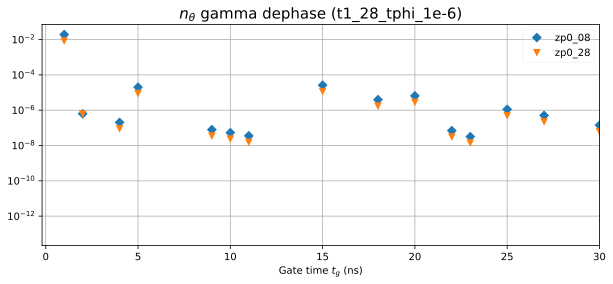

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
plt.plot(zp0['decay_2us_0'], 'D', label=r'zp0_08')
plt.plot(zp0['decay_2us_2'], 'v', label=r'zp0_28')
plt.xlim(-0.2,30)
# plt.ylim(0,)
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'$n_\theta$ gamma dephase (t1_28_tphi_1e-6)', fontsize=15)
plt.grid()
legend = plt.legend( loc="best")
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

# calc decay / dephasing rate for single zero pi

In [ ]:
folder = '../../data/3ncut_one_zeropi/'
eval_0 = scq.read(folder + f'zeropi_0_specdata_truc=1000_3ncut.h5').energy_table
n_theta0 = scq.read(folder + f'zeropi_0_n_theta_truc=1000_3ncut.h5').matrixelem_table
n_phi0 = scq.read(folder + f'zeropi_0_n_phi_truc=1000_3ncut.h5').matrixelem_table
eval_0 = eval_0 - eval_0[0]
eval_1 = scq.read(folder + f'zeropi_1_specdata_truc=1000_3ncut.h5').energy_table
n_theta1 = scq.read(folder + f'zeropi_1_n_theta_truc=1000_3ncut.h5').matrixelem_table
n_phi1 = scq.read(folder + f'zeropi_1_n_phi_truc=1000_3ncut.h5').matrixelem_table
eval_1 = eval_1 - eval_1[0]


In [ ]:
# truc1 = 300
# hspace_0 = [0, 2]
# hspace_1 = [0, 2]
# for s in hspace_0:
#     for i in range(truc1):
#         if np.abs(n_theta0[s, i]) > 0.001 and i not in hspace_0:
#             hspace_0.append(i)
# hspace_0.sort()
# for s in hspace_1:
#     for i in range(truc1):
#         if np.abs(n_theta1[s, i]) > 0.001 and i not in hspace_1:
#             hspace_1.append(i)
# hspace_1.sort()

# print(len(hspace_0), len(hspace_1))
# for i in range(0, len(hspace_0), 10):
#     print(', '.join(map(str, np.round(hspace_0[i:i+10], 8))), ',')
# for i in range(0, len(hspace_1), 10):
#     print(', '.join(map(str, np.round(hspace_1[i:i+10], 8))), ',')

157 157
0, 1, 2, 4, 5, 7, 8, 11, 12, 16 ,
17, 18, 21, 23, 25, 27, 30, 31, 32, 33 ,
37, 38, 40, 41, 42, 45, 46, 47, 48, 51 ,
52, 56, 59, 62, 63, 64, 65, 67, 72, 73 ,
74, 76, 78, 79, 82, 83, 85, 87, 88, 90 ,
92, 93, 96, 97, 98, 102, 103, 106, 107, 112 ,
114, 118, 119, 120, 121, 122, 123, 124, 127, 128 ,
131, 132, 133, 134, 137, 138, 142, 143, 150, 151 ,
154, 155, 156, 157, 158, 161, 162, 163, 166, 170 ,
171, 174, 175, 176, 177, 179, 180, 186, 187, 188 ,
191, 192, 195, 196, 199, 202, 203, 206, 207, 208 ,
210, 213, 214, 218, 219, 220, 221, 222, 225, 226 ,
230, 231, 232, 236, 237, 238, 242, 243, 246, 247 ,
248, 251, 252, 258, 259, 260, 262, 263, 264, 270 ,
271, 274, 275, 279, 280, 281, 283, 284, 285, 288 ,
289, 290, 294, 296, 297, 298, 299 ,
0, 1, 2, 4, 5, 7, 8, 11, 13, 16 ,
17, 18, 20, 23, 25, 27, 30, 31, 32, 33 ,
36, 38, 40, 41, 42, 44, 45, 47, 48, 53 ,
54, 56, 59, 60, 63, 64, 65, 66, 70, 73 ,
74, 75, 79, 80, 82, 83, 84, 88, 89, 90 ,
92, 93, 96, 97, 98, 102, 105, 106, 107, 112 ,
114, 118,

In [ ]:
hspace_0 = [
0, 1, 2, 4, 5, 7, 8, 11, 12, 16 ,
17, 18, 21, 23, 25, 27, 30, 31, 32, 33 ,
37, 38, 40, 41, 42, 45, 46, 47, 48, 51 ,
52, 56, 59, 62, 63, 64, 65, 67, 72, 73 ,
74, 76, 78, 79, 82, 83, 85, 87, 88, 90 ,
92, 93, 96, 97, 98, 102, 103, 106, 107, 112 ,
114, 118, 119, 120, 121, 122, 123, 124, 127, 128 ,
131, 132, 133, 134, 137, 138, 142, 143, 150, 151 ,
154, 155, 156, 157, 158, 161, 162, 163, 166, 170 ,
171, 174, 175, 176, 177, 179, 180, 186, 187, 188 ,
191, 192, 195, 196, 199, 202, 203, 206, 207, 208 ,
210, 213, 214, 218, 219, 220, 221, 222, 225, 226 ,
230, 231, 232, 236, 237, 238, 242, 243, 246, 247 ,
248, 251, 252, 258, 259, 260, 262, 263, 264, 270 ,
271, 274, 275, 279, 280, 281, 283, 284, 285, 288 ,
289, 290, 294, 296, 297, 298, 299 ,
]
hspace_1 = [
0, 1, 2, 4, 5, 7, 8, 11, 13, 16 ,
17, 18, 20, 23, 25, 27, 30, 31, 32, 33 ,
36, 38, 40, 41, 42, 44, 45, 47, 48, 53 ,
54, 56, 59, 60, 63, 64, 65, 66, 70, 73 ,
74, 75, 79, 80, 82, 83, 84, 88, 89, 90 ,
92, 93, 96, 97, 98, 102, 105, 106, 107, 112 ,
114, 118, 119, 120, 121, 122, 123, 124, 127, 128 ,
131, 132, 133, 134, 138, 139, 141, 142, 150, 151 ,
154, 155, 156, 157, 158, 161, 164, 165, 166, 170 ,
171, 174, 175, 176, 177, 179, 180, 186, 187, 188 ,
189, 190, 195, 196, 199, 202, 203, 206, 207, 208 ,
212, 213, 214, 217, 219, 220, 221, 222, 225, 226 ,
230, 231, 232, 236, 237, 238, 242, 243, 244, 245 ,
248, 251, 252, 258, 259, 260, 262, 263, 264, 270 ,
273, 274, 275, 276, 277, 279, 283, 284, 285, 288 ,
289, 290, 295, 296, 297, 298, 299 ,
]

In [ ]:
folder1 = '../../data/3ncut_one_zeropi/'
zp0 = pd.read_csv( folder1 + 'zeropi_0_eval.txt')
zp1 = pd.read_csv( folder1 + 'zeropi_1_eval.txt')
dw_dphi_q0 = [np.abs(zp0['eval_flux=0.001'][i] - zp0['eval_flux=0'][i]) / 0.001 for i in hspace_0]
dw_dphi_q1 = [np.abs(zp1['eval_flux=0.001'][i] - zp1['eval_flux=0'][i]) / 0.001 for i in hspace_1]

w_ir = 1e-9* 2 * np.pi # 1 Hz
t = 10e3 # 10 us = 10e3 ns
A0 = 1e-6
A1 = 1e-6
gamma_tphi_1e6_qubit0 = A0 * np.array(dw_dphi_q0) * np.sqrt(2 * np.abs(np.log(w_ir * t)))
gamma_tphi_1e6_qubit1 = A1 * np.array(dw_dphi_q1) * np.sqrt(2 * np.abs(np.log(w_ir * t)))

print( 'gamma_dephase_qubit0=' ,gamma_tphi_1e6_qubit0.tolist())
print( '\ngamma_dephase_qubit1=' ,gamma_tphi_1e6_qubit1.tolist())

gamma_dephase_qubit0= [0.0, 3.205558446426136e-10, 1e-05, 1.1908375680424673e-09, 2.482262153125313e-06, 8.010444411678562e-10, 4.882066742575772e-07, 2.4379974092560418e-08, 1.0006582262103586e-06, 2.0676554106138076e-07, 2.651647545565418e-10, 2.698216643016875e-07, 1.4534141884145369e-07, 1.2450058321902464e-05, 6.081310028493021e-07, 1.990009147861666e-07, 1.0681908617403839e-06, 1.3214896356588352e-07, 8.074833284440567e-08, 2.604431255123769e-08, 7.160737996704374e-07, 2.8437358702639297e-08, 3.314617478195063e-07, 2.5775075889618824e-08, 1.0240786719294486e-08, 8.692166152473113e-07, 1.2150991257835336e-07, 1.065250312425472e-07, 3.9102457797778746e-07, 2.282083263778189e-07, 1.91960935923803e-07, 4.725347240899856e-08, 1.2323393775597673e-07, 1.5199617640310262e-06, 2.3725589211170067e-07, 9.536039822543888e-08, 1.794565428857527e-07, 1.1852983726113432e-06, 4.473615406482101e-07, 4.525859404360967e-07, 6.320426060011908e-08, 9.998565080095594e-09, 1.8189309071747355e-06, 4.255

## Average Flux Derivative

In [ ]:
# folder = f'../../data/3ncut_two_zeropi/truc1=500/'
# n_theta0 = np.load(folder+'n_theta0.npy')
# n_theta1 = np.load(folder+'n_theta1.npy')
# eval0 = pd.read_csv(folder+ 'eval0.txt').to_numpy().flatten()
# eval1 = pd.read_csv(folder+ 'eval1.txt').to_numpy().flatten()
# folder = f'../../data/3ncut_two_zeropi/truc1=500/'
# eval0_flux = pd.read_csv(folder+ 'eval0_flux=0.001.txt').to_numpy().flatten()
# eval1_flux = pd.read_csv(folder+ 'eval1_flux=0.001.txt').to_numpy().flatten()

# truc1, truc_tot, charge_pick = 300, 1000, True
# folder = f'../../data/3ncut_two_zeropi/truc1={truc1}_truc2={truc_tot}_pick={charge_pick}/'
# hspace_0 = pd.read_csv(folder+ 'hspace_0.txt').to_numpy().flatten().tolist()
# hspace_1 = pd.read_csv(folder+ 'hspace_1.txt').to_numpy().flatten().tolist()
# hspace_full = pd.read_csv(folder+ 'hspace_full.txt').to_numpy().flatten().tolist()
# print('len(hspace_0)=', len(hspace_0))
# print('len(hspace_1)=', len(hspace_1))
# print('hspace_0=', hspace_0)
# print('hspace_1=', hspace_1)

In [ ]:


eval0_flux_0 = 2 * np.pi * hd.load_single_qubit_data('../data/Single_qubit_1_flux_0', return_full=True)['evals']
eval0_flux_0 = eval0_flux_0 - eval0_flux_0[0]

eval0_flux = 2 * np.pi * hd.load_single_qubit_data('../data/Single_qubit_1_flux_0.1', return_full=True)['evals']
eval0_flux_1 = eval0_flux - eval0_flux[0]
dw_q0_1 = np.array([np.abs(eval0_flux_1[i] - eval0_flux_0[i]) for i in hspace_0])
dw_dphi_q0_1 = dw_q0_1 / 0.1

eval0_flux = 2 * np.pi * hd.load_single_qubit_data('../data/Single_qubit_1_flux_0.01', return_full=True)['evals']
eval0_flux_01 = eval0_flux - eval0_flux[0]
dw_q0_01 = np.array([np.abs(eval0_flux_01[i] - eval0_flux_0[i]) for i in hspace_0])
dw_dphi_q0_01 = dw_q0_01 / 0.01

eval0_flux = 2 * np.pi * hd.load_single_qubit_data('../data/Single_qubit_1_flux_0.001', return_full=True)['evals']
eval0_flux_001 = eval0_flux - eval0_flux[0]
dw_q0_001 = np.array([np.abs(eval0_flux_001[i] - eval0_flux_0[i]) for i in hspace_0])
dw_dphi_q0_001 = dw_q0_001 / 0.001

eval0_flux = 2 * np.pi * hd.load_single_qubit_data('../data/Single_qubit_1_flux_0.0001', return_full=True)['evals']
eval0_flux_0001 = eval0_flux - eval0_flux[0]
dw_q0_0001 = np.array([np.abs(eval0_flux_0001[i] - eval0_flux_0[i]) for i in hspace_0])
dw_dphi_q0_0001 = dw_q0_0001 / 0.0001

eval0_flux = 2 * np.pi * hd.load_single_qubit_data('../data/Single_qubit_1_flux_0.00001', return_full=True)['evals']
eval0_flux_00001 = eval0_flux - eval0_flux[0]
dw_q0_00001 = np.array([np.abs(eval0_flux_00001[i] - eval0_flux_0[i]) for i in hspace_0])
dw_dphi_q0_00001 = dw_q0_00001 / 0.00001

# print('len(hspace_0)=', len(hspace_0))
# print('len(hspace_1)=', len(hspace_1))
# print('len(hspace_full)=', len(hspace_full))

# print(f'len(eval0)={len(eval0)}')
# print(f'len(eval0_flux)={len(eval0_flux)}')

# print(f'hspace_0[:10]={hspace_0[:10]}')
# print(f'hspace_1[:10]={hspace_1[:10]}')

len(hspace_0)= 154
len(hspace_1)= 155
len(hspace_full)= 3000
len(eval0)=300
len(eval0_flux)=1000
hspace_0[:10]=[0, 1, 2, 4, 5, 8, 9, 12, 13, 15]
hspace_1[:10]=[0, 1, 2, 4, 5, 8, 9, 12, 13, 16]


In [ ]:
k=5
print(f'{eval0_flux_0[:k]=    }')
print(f'{eval0_flux_1[:k]=    }')
print(f'{eval0_flux_01[:k]=   }')
print(f'{eval0_flux_001[:k]=  }')
print(f'{eval0_flux_0001[:k]= }')
print(f'{eval0_flux_00001[:k]=}')
print(f'{eval0[:k]=           }')
print(f'{eval1[:k]=           }')


eval0_flux_0[:k]=    array([ 0.        , 15.75322963, 21.37868308, 21.52825164, 30.44459994])
eval0_flux_1[:k]=    array([ 0.        , 15.7486436 , 17.1654589 , 25.73800892, 30.42758242])
eval0_flux_01[:k]=   array([ 0.        , 15.75318384, 21.01838474, 21.88851699, 30.44442984])
eval0_flux_001[:k]=  array([ 0.        , 15.75322917, 21.36727213, 21.53966226, 30.44459824])
eval0_flux_0001[:k]= array([ 0.        , 15.75322962, 21.37856037, 21.52837435, 30.44459992])
eval0_flux_00001[:k]=array([ 0.        , 15.75322963, 21.37868185, 21.52825286, 30.44459994])
eval0[:k]=           array([ 0.        , 16.20354681, 21.63551922, 21.63952403, 31.56887863])
eval1[:k]=           array([ 0.        , 15.2573613 , 21.42536827, 21.43355993, 29.65058859])


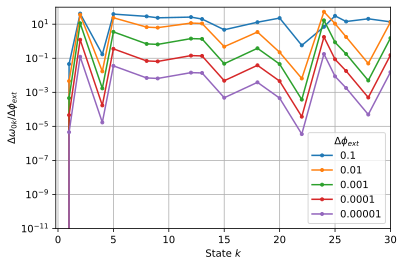

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
# ax.plot(hspace_0, dw_dphi_q0_1, '.-', label='$0.1$')
ax.plot(hspace_0, dw_dphi_q0_01, '.-', label='$0.01$')
ax.plot(hspace_0, dw_dphi_q0_001, '.-', label='$0.001$')
ax.plot(hspace_0, dw_dphi_q0_0001, '.-', label='$0.0001$')
ax.plot(hspace_0, dw_dphi_q0_00001, '.-', label='$0.00001$')
ax.legend(title='$\Delta \phi_{ext}$')
ax.set_xlabel('State $k$')
ax.set_ylabel('$\Delta \omega_{0k} / \Delta \phi_{ext}$')
ax.set_yscale('log')
ax.set_xlim(-0.2, 30)
ax.set_ylim(1e-11, 1e2)
ax.grid()
plt.show()

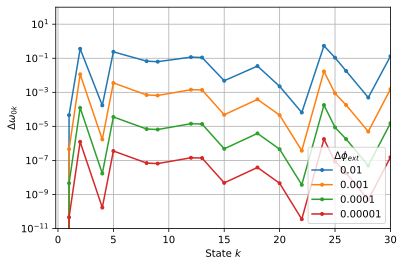

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
# ax.plot(hspace_0, dw_q0_1, '.-', label='$0.1$')
ax.plot(hspace_0, dw_q0_01, '.-', label='$0.01$')
ax.plot(hspace_0, dw_q0_001, '.-', label='$0.001$')
ax.plot(hspace_0, dw_q0_0001, '.-', label='$0.0001$')
ax.plot(hspace_0, dw_q0_00001, '.-', label='$0.00001$')
ax.legend(title='$\Delta \phi_{ext}$', loc='lower right')
ax.set_xlabel('State $k$')
ax.set_ylabel('$\Delta \omega_{0k}$')
ax.set_yscale('log')
ax.set_xlim(-0.2, 30)
ax.set_ylim(1e-11, 1e2)
ax.grid()
plt.show()

In [ ]:
dim = 10
qt.Qobj(n_theta0[:dim, :dim]).tidyup(atol=1e-5)

Quantum object: dims = [[10], [10]], shape = (10, 10), type = oper, isherm = True
Qobj data =
[[  0.          -8.49708993   0.           0.           0.
   -0.02743875   0.           0.          -0.27503083   0.        ]
 [ -8.49708993   0.           0.06430213   0.         -11.68763601
    0.           0.           0.           0.          -0.34177736]
 [  0.           0.06430213   0.           0.           0.
   -8.38647187   0.           0.           0.40166629   0.        ]
 [  0.           0.           0.           0.           0.
    0.          -8.39954739   0.           0.           0.        ]
 [  0.         -11.68763601   0.           0.           0.
   -0.88234174   0.           0.         -13.71113166   0.        ]
 [ -0.02743875   0.          -8.38647187   0.          -0.88234174
    0.           0.           0.           0.          10.8319286 ]
 [  0.           0.           0.          -8.39954739   0.
    0.           0.           0.25945309   0.           0.        ]
 

In [ ]:
dim = 10
qt.Qobj(n_theta1[:dim, :dim]).tidyup(atol=1e-5)

Quantum object: dims = [[10], [10]], shape = (10, 10), type = oper, isherm = True
Qobj data =
[[  0.          -8.24474197   0.           0.           0.
   -0.04735869   0.           0.          -0.29017179   0.        ]
 [ -8.24474197   0.           0.11621067   0.         -11.30705671
    0.           0.           0.           0.          -0.50176509]
 [  0.           0.11621067   0.           0.           0.
   -8.08169802   0.           0.           0.71429086   0.        ]
 [  0.           0.           0.           0.           0.
    0.          -8.12017937   0.           0.           0.        ]
 [  0.         -11.30705671   0.           0.           0.
   -1.49380806   0.           0.         -13.12203364   0.        ]
 [ -0.04735869   0.          -8.08169802   0.          -1.49380806
    0.           0.           0.           0.           9.74207617]
 [  0.           0.           0.          -8.12017937   0.
    0.           0.           0.40193341   0.           0.        ]
 